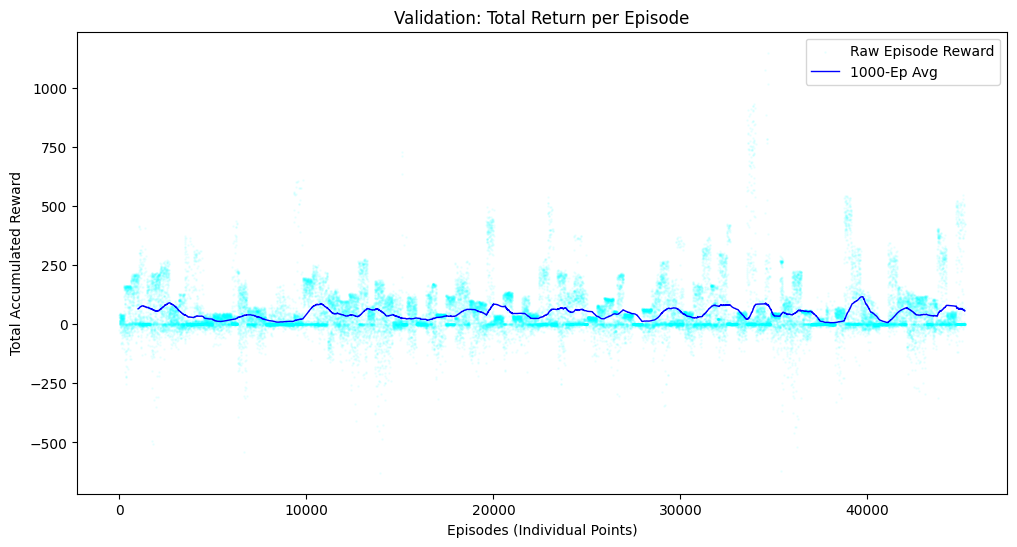

In [3]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load the existing data
with open("validation_stats.json", "r") as f:
    stats = json.load(f)

ep_rewards = stats["episode_rewards"]
episodes = np.arange(len(ep_rewards))

plt.figure(figsize=(12, 6))
# Faint scatter to handle the 100k+ points
plt.scatter(episodes, ep_rewards, alpha=0.05, color='cyan', s=1, label='Raw Episode Reward')

# Add a moving average to see the trend
window = 1000
if len(ep_rewards) > window:
    ma = np.convolve(ep_rewards, np.ones(window)/window, mode='valid')
    plt.plot(np.arange(window-1, len(ep_rewards)), ma, color='blue', linewidth=1, label=f'{window}-Ep Avg')

plt.title("Validation: Total Return per Episode")
plt.xlabel("Episodes (Individual Points)")
plt.ylabel("Total Accumulated Reward")
plt.legend()
plt.savefig("val_plot_episode_returns.png", dpi=300)
plt.show()

In [ ]:
# --- FIXED Action Distribution Logic ---
test_stats = {
    "episode_rewards": [],
    "episode_lengths": [],
    "avg_rewards": [],
    "survival_rates": [],
    "action_distributions": []
}

vid_window  = 5

perc_kill, perc_keep, perc_reanchor = [], [], []

for dist in test_stats["action_distributions"]:
    # FIX: Use integer keys (0, 1, 2) to match your 'video_actions' initialization
    total = dist.get(0, 0) + dist.get(1, 0) + dist.get(2, 0)
    
    if total == 0:
        perc_kill.append(0); perc_keep.append(0); perc_reanchor.append(0)
    else:
        # Selection Percentage (%)
        perc_kill.append(dist.get(0, 0) / total * 100)
        perc_keep.append(dist.get(1, 0) / total * 100)
        perc_reanchor.append(dist.get(2, 0) / total * 100)

plt.figure(figsize=(10, 6))
if vid_window > 0:
    plt.plot(np.arange(vid_window-1, len(perc_keep)), moving_average(perc_keep, vid_window), color='blue', label='Keep (1)')
    plt.plot(np.arange(vid_window-1, len(perc_kill)), moving_average(perc_kill, vid_window), color='red', label='Kill (0)')
    plt.plot(np.arange(vid_window-1, len(perc_reanchor)), moving_average(perc_reanchor, vid_window), color='orange', label='Re-anchor (2)')

plt.title(f"Evaluation: Action Distribution ({vid_window}-Vid Avg)")
plt.xlabel("Validation Videos")
plt.ylabel("Selection Percentage (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("val_plot_actions_fixed.png", dpi=300)


NameError: name 'vid_window' is not defined

<Figure size 1000x600 with 0 Axes>